# SMOTE influence on metrics

This notebook evaluates the influence of using SMOTE and SMOTENC, both with default parameters, on the resulting metrics. For SMOTENC, the features "wettability" and "inclination" were provided.

# Prerequisites

In [1]:
import os
from pathlib import Path
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import re
import ast

## Functions

In [2]:

def get_best_SMOTE_type(
    df:pd.DataFrame,
    metric_lists:list[list[str]]=None,
):
    """This function retrieves the best SMOTE type for each model class based on specified metrics.

    Args:
        df: DataFrame containing model performance metrics.
        metric_lists: List of metric names to evaluate. Defaults to None.
    """
    if metric_lists is None:
        metric_lists = [
            ['holdout_test_f1_macro', 'holdout_test_roc_auc', 'holdout_test_accuracy_balanced',],
            ['cv_test_f1_macro_median', 'cv_test_roc_auc_median', 'cv_test_accuracy_balanced_median',],
        ]


    metrics_by_target = {
        target: df[df['target'] == target]
        for target in df['target'].unique()
    }

    for target in metrics_by_target:
        # smote_by_target = {}
        for metric_list in metric_lists:
            print(target.upper())
            display(metric_list)
            metrics = metrics_by_target[target].groupby(
                ['model_class', 'SMOTE_type']
            )[metric_list].median()

            metrics = metrics.sort_values(by=metric_list, ascending=False)

            result = metrics.reset_index().groupby('model_class')['SMOTE_type'].first()

            display(result)
            print('Best SMOTE type:', result.value_counts().idxmax())
            display(metrics)
            
            # smote_by_target[target] = result
            

# # NOTE: Potentially no need, since now there might be no callable in params
# def remove_callable(s:str):
#     """This function removes the callable from the string."""
    
#     # pattern = r"('estimator'\s*:\s*)([^,}]+)"
#     # pattern = r"('estimator'\s*:\s*)([^\)]*\))"
#     # pattern = r"('estimator'\s*:\s*)(.*?)(?=, \')"
#     pattern = r"('estimator'\s*:\s*)(.*?)(?=,\s*'estimator_params')"
#     return re.sub(pattern, r"\1'\2'", s)


## Load Data

In [3]:
df_metrics = pd.read_excel(
    Path(
        '../results/metrics_modelling4.xlsx'
    ),
)
# df_metrics['params'] = df_metrics['params'].apply(remove_callable)

display(df_metrics.head())
df_metrics.info()

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_class_0_mean,cv_train_recall_class_0_median,cv_train_recall_class_0_std,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std
0,df_dimless,splashing,Logit_splashing_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.800000,0.823529,0.875000,0.848485,0.874228,0.777184,...,0.784073,0.778761,0.017802,0.845821,0.844660,0.010156,"0.8959421541118067, 0.9114676936243047, 0.9020...",0.905980,0.907788,0.006070
1,df_dimless,no_fragmentation,Logit_no_fragmentation_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.906667,0.809524,0.850000,0.829268,0.951818,0.882524,...,0.916361,0.914530,0.012056,0.760984,0.752941,0.021087,"0.9395604395604396, 0.9486676721970839, 0.9361...",0.940673,0.941277,0.005873
2,df_dimless,splashing,LogisticRegression_splashing_default,"{'estimator': 'LogisticRegression', 'estimator...",0.800000,0.823529,0.875000,0.848485,0.879630,0.777184,...,0.803036,0.796460,0.021463,0.838192,0.834951,0.009285,"0.8971077055903303, 0.912665810868635, 0.90327...",0.907306,0.909206,0.006459
3,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_default,"{'estimator': 'LogisticRegression', 'estimator...",0.826667,0.629630,0.850000,0.723404,0.946364,0.798595,...,0.843712,0.846154,0.010179,0.878792,0.870588,0.014996,"0.9391534391534391, 0.949270990447461, 0.93559...",0.940457,0.941679,0.005749
4,df_dimless,splashing,KNeighborsClassifier_splashing_default,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.853333,0.862745,0.916667,0.888889,0.880787,0.836601,...,0.845942,0.849558,0.017741,0.916667,0.917476,0.010215,"0.9670192100151089, 0.9732563115104835, 0.9687...",0.968172,0.967738,0.002594


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Columns: 112 entries, dataset to cv_train_roc_auc_std
dtypes: float64(86), object(26)
memory usage: 147.1+ KB


## Apply SMOTE and pure model groups

In [4]:
df_metrics['model'].str.split('_').apply(lambda x: x[2:])

0                                              [default]
1                               [fragmentation, default]
2                                              [default]
3                               [fragmentation, default]
4                                              [default]
                             ...                        
163    [fragmentation, smotenc, optuna-opt-mean-smote...
164      [smotenc, optuna-opt-mean-smote, default-model]
165    [fragmentation, smotenc, optuna-opt-mean-smote...
166      [smotenc, optuna-opt-mean-smote, default-model]
167    [fragmentation, smotenc, optuna-opt-mean-smote...
Name: model, Length: 168, dtype: object

In [5]:
df_metrics['model_class'] = df_metrics['model'].apply(
    lambda x: x.split('_')[0]
)

df_metrics['model_group'] = df_metrics['model'].apply(
    lambda x: x.split('_')[-1]
)
df_metrics['model_group'] = df_metrics['model_group'].apply(
    lambda x: 'default' if 'default' in x else 'opt'
)

def define_SMOTE_type(model):
    if 'smotenc' in model:
        return 'SMOTENC'
    elif 'smote' in model:
        return 'SMOTE'
    else:
        return 'No'
df_metrics['SMOTE_type'] = df_metrics['model'].apply(
    define_SMOTE_type
)

df_metrics.head()

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std,model_class,model_group,SMOTE_type
0,df_dimless,splashing,Logit_splashing_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.800000,0.823529,0.875000,0.848485,0.874228,0.777184,...,0.845821,0.844660,0.010156,"0.8959421541118067, 0.9114676936243047, 0.9020...",0.905980,0.907788,0.006070,Logit,default,No
1,df_dimless,no_fragmentation,Logit_no_fragmentation_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.906667,0.809524,0.850000,0.829268,0.951818,0.882524,...,0.760984,0.752941,0.021087,"0.9395604395604396, 0.9486676721970839, 0.9361...",0.940673,0.941277,0.005873,Logit,default,No
2,df_dimless,splashing,LogisticRegression_splashing_default,"{'estimator': 'LogisticRegression', 'estimator...",0.800000,0.823529,0.875000,0.848485,0.879630,0.777184,...,0.838192,0.834951,0.009285,"0.8971077055903303, 0.912665810868635, 0.90327...",0.907306,0.909206,0.006459,LogisticRegression,default,No
3,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_default,"{'estimator': 'LogisticRegression', 'estimator...",0.826667,0.629630,0.850000,0.723404,0.946364,0.798595,...,0.878792,0.870588,0.014996,"0.9391534391534391, 0.949270990447461, 0.93559...",0.940457,0.941679,0.005749,LogisticRegression,default,No
4,df_dimless,splashing,KNeighborsClassifier_splashing_default,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.853333,0.862745,0.916667,0.888889,0.880787,0.836601,...,0.916667,0.917476,0.010215,"0.9670192100151089, 0.9732563115104835, 0.9687...",0.968172,0.967738,0.002594,KNeighborsClassifier,default,No


In [6]:
df_metrics['model_group'].value_counts()

default    150
opt         18
Name: model_group, dtype: int64

## Get best SMOTE types

In [5]:
df = df_metrics[
    ~df_metrics['SMOTE_type'].isin(['OPT-SMOTE', 'OPT-SMOTENC'])
] 

get_best_SMOTE_type(df=df)

SPLASHING


['holdout_test_f1_macro',
 'holdout_test_roc_auc',
 'holdout_test_accuracy_balanced']

model_class
AdaBoostClassifier             No
CatBoostClassifier          SMOTE
KNeighborsClassifier           No
LGBMClassifier                 No
LogisticRegression             No
Logit                          No
RandomForestClassifier      SMOTE
SVC                         SMOTE
XGBClassifier             SMOTENC
Name: SMOTE_type, dtype: object

Best SMOTE type: No


holdout_test_f1_macro  \
model_class            SMOTE_type                          
CatBoostClassifier     SMOTE                    0.882261   
XGBClassifier          SMOTENC                  0.880000   
CatBoostClassifier     SMOTENC                  0.868703   
LGBMClassifier         No                       0.866310   
CatBoostClassifier     No                       0.863609   
XGBClassifier          SMOTE                    0.863609   
                       No                       0.863609   
LGBMClassifier         SMOTENC                  0.852826   
                       SMOTE                    0.852826   
RandomForestClassifier SMOTE                    0.850000   
                       No                       0.850000   
                       SMOTENC                  0.836601   
KNeighborsClassifier   No                       0.836601   
                       SMOTENC                  0.829027   
SVC                    SMOTE                    0.810348   
                       SMOTENC                  0.810348   
KNeighborsClassifier   SMOTE                    0.803223   
SVC                    No                       0.793956   
AdaBoostClassifier     No                       0.793956   
LogisticRegression     No                       0.777184   
Logit                  No                       0.777184   
LogisticRegression     SMOTE                    0.772036   
Logit                  SMOTENC                  0.764521   
                       SMOTE                    0.764521   
LogisticRegression     SMOTENC                  0.755981   
AdaBoostClassifier     SMOTE                    0.751994   
                       SMOTENC                  0.751994   

                                   holdout_test_roc_auc  \
model_class            SMOTE_type                         
CatBoostClassifier     SMOTE                   0.952932   
XGBClassifier          SMOTENC                 0.932485   
CatBoostClassifier     SMOTENC                 0.949846   
LGBMClassifier         No                      0.951775   
CatBoostClassifier     No                      0.956790   
XGBClassifier          SMOTE                   0.942515   
                       No                      0.940972   
LGBMClassifier         SMOTENC                 0.957562   
                       SMOTE                   0.949074   
RandomForestClassifier SMOTE                   0.944444   
                       No                      0.943673   
                       SMOTENC                 0.938657   
KNeighborsClassifier   No                      0.880787   
                       SMOTENC                 0.887346   
SVC                    SMOTE                   0.885031   
                       SMOTENC                 0.877315   
KNeighborsClassifier   SMOTE                   0.887346   
SVC                    No                      0.911265   
AdaBoostClassifier     No                      0.881559   
LogisticRegression     No                      0.879630   
Logit                  No                      0.874228   
LogisticRegression     SMOTE                   0.879630   
Logit                  SMOTENC                 0.871142   
                       SMOTE                   0.868827   
LogisticRegression     SMOTENC                 0.878858   
AdaBoostClassifier     SMOTE                   0.839892   
                       SMOTENC                 0.830633   

                                   holdout_test_accuracy_balanced  
model_class            SMOTE_type                                  
CatBoostClassifier     SMOTE                             0.876157  
XGBClassifier          SMOTENC                           0.868056  
CatBoostClassifier     SMOTENC                           0.865741  
LGBMClassifier         No                                0.857639  
CatBoostClassifier     No                                0.849537  
XGBClassifier          SMOTE                             0.849537  
                       No             

...

NO_FRAGMENTATION


['cv_test_f1_macro_median',
 'cv_test_roc_auc_median',
 'cv_test_accuracy_balanced_median']

model_class
AdaBoostClassifier          SMOTE
CatBoostClassifier          SMOTE
KNeighborsClassifier      SMOTENC
LGBMClassifier                 No
LogisticRegression             No
Logit                       SMOTE
RandomForestClassifier      SMOTE
SVC                       SMOTENC
XGBClassifier                  No
Name: SMOTE_type, dtype: object

Best SMOTE type: SMOTE


cv_test_f1_macro_median  \
model_class            SMOTE_type                            
CatBoostClassifier     SMOTE                      0.925457   
                       SMOTENC                    0.902930   
                       No                         0.898077   
LGBMClassifier         No                         0.898077   
                       SMOTE                      0.886022   
                       SMOTENC                    0.886022   
SVC                    SMOTENC                    0.881326   
KNeighborsClassifier   SMOTENC                    0.881326   
XGBClassifier          No                         0.875762   
                       SMOTENC                    0.875762   
                       SMOTE                      0.875762   
RandomForestClassifier SMOTE                      0.875762   
                       SMOTENC                    0.875762   
                       No                         0.869136   
LogisticRegression     No                         0.854396   
SVC                    SMOTE                      0.850704   
KNeighborsClassifier   SMOTE                      0.850704   
AdaBoostClassifier     SMOTE                      0.850704   
KNeighborsClassifier   No                         0.835007   
Logit                  SMOTE                      0.828299   
AdaBoostClassifier     SMOTENC                    0.826067   
                       No                         0.826067   
Logit                  No                         0.814035   
                       SMOTENC                    0.814035   
LogisticRegression     SMOTE                      0.813161   
                       SMOTENC                    0.813161   
SVC                    No                         0.796154   

                                   cv_test_roc_auc_median  \
model_class            SMOTE_type                           
CatBoostClassifier     SMOTE                     0.977778   
                       SMOTENC                   0.974359   
                       No                        0.974359   
LGBMClassifier         No                        0.958974   
                       SMOTE                     0.976068   
                       SMOTENC                   0.974359   
SVC                    SMOTENC                   0.963370   
KNeighborsClassifier   SMOTENC                   0.927656   
XGBClassifier          No                        0.979487   
                       SMOTENC                   0.967033   
                       SMOTE                     0.967033   
RandomForestClassifier SMOTE                     0.953846   
                       SMOTENC                   0.940171   
                       No                        0.952991   
LogisticRegression     No                        0.945055   
SVC                    SMOTE                     0.957875   
KNeighborsClassifier   SMOTE                     0.952381   
AdaBoostClassifier     SMOTE                     0.934066   
KNeighborsClassifier   No                        0.932234   
Logit                  SMOTE                     0.935897   
AdaBoostClassifier     SMOTENC                   0.930403   
                       No                        0.912088   
Logit                  No                        0.932234   
                       SMOTENC                   0.930403   
LogisticRegression     SMOTE                     0.943223   
                       SMOTENC                   0.939560   
SVC                    No                        0.943223   

                                   cv_test_accuracy_balanced_median  
model_class            SMOTE_type                                    
CatBoostClassifier     SMOTE                               0.915751  
                       SMOTENC                             0.902930  
                       No                                  0.880037  
LGBMClassifier         No                                  0.890110  
                       SMOTE                  

## **Preliminary conclusions (before fixing random_state):**
- For Logit, there is sufficient justification for not using SMOTE[NC], even without considering statistical significance.
- For CV metrics, the best choice (based on the number of models with the best metric scores) was **SMOTE**.
- For holdout, the absence of SMOTE/SMOTENC is preferable.

## Conclusions after fixing random_state:
- For Logit, there is sufficient justification for not using SMOTE[NC], even without considering statistical significance. Only logit for no_fragmentation and only on CV_metrics gives, that SMOTE is better
- For Splashing No SMOTE or at least SMOTE is good for holdout, however SMOTENC good for CV
- For "No fragmentation", SMOTENC and SMOTE appears equal number of times, while for CV SMOTE is preferable

Thus, for all models except the non-optimizable Logit, SMOTE is used.

# Best choice, including OPT-SMOTE

Now, let us include OPT-SMOTE in consideration of the best method

In [6]:
df = df_metrics

get_best_SMOTE_type(df=df)

SPLASHING


['holdout_test_f1_macro',
 'holdout_test_roc_auc',
 'holdout_test_accuracy_balanced']

model_class
AdaBoostClassifier                 No
CatBoostClassifier              SMOTE
KNeighborsClassifier               No
LGBMClassifier                     No
LogisticRegression          OPT-SMOTE
Logit                              No
RandomForestClassifier          SMOTE
SVC                       OPT-SMOTENC
XGBClassifier             OPT-SMOTENC
Name: SMOTE_type, dtype: object

Best SMOTE type: No


holdout_test_f1_macro  \
model_class            SMOTE_type                           
XGBClassifier          OPT-SMOTENC               0.896019   
CatBoostClassifier     SMOTE                     0.882261   
XGBClassifier          SMOTENC                   0.880000   
CatBoostClassifier     SMOTENC                   0.868703   
LGBMClassifier         No                        0.866310   
CatBoostClassifier     No                        0.863609   
XGBClassifier          SMOTE                     0.863609   
                       No                        0.863609   
LGBMClassifier         SMOTENC                   0.852826   
                       SMOTE                     0.852826   
XGBClassifier          OPT-SMOTE                 0.852826   
RandomForestClassifier SMOTE                     0.850000   
                       No                        0.850000   
CatBoostClassifier     OPT-SMOTE                 0.846814   
LGBMClassifier         OPT-SMOTE                 0.836601   
                       OPT-SMOTENC               0.836601   
RandomForestClassifier SMOTENC                   0.836601   
KNeighborsClassifier   No                        0.836601   
RandomForestClassifier OPT-SMOTE                 0.833300   
KNeighborsClassifier   SMOTENC                   0.829027   
CatBoostClassifier     OPT-SMOTENC               0.823391   
SVC                    OPT-SMOTENC               0.810348   
                       SMOTE                     0.810348   
                       SMOTENC                   0.810348   
KNeighborsClassifier   OPT-SMOTE                 0.810348   
RandomForestClassifier OPT-SMOTENC               0.806892   
KNeighborsClassifier   SMOTE                     0.803223   
SVC                    No                        0.793956   
                       OPT-SMOTE                 0.793956   
LogisticRegression     OPT-SMOTE                 0.793956   
AdaBoostClassifier     No                        0.793956   
LogisticRegression     OPT-SMOTENC               0.793956   
KNeighborsClassifier   OPT-SMOTENC               0.784689   
LogisticRegression     No                        0.777184   
Logit                  No                        0.777184   
LogisticRegression     SMOTE                     0.772036   
AdaBoostClassifier     OPT-SMOTENC               0.764521   
Logit                  SMOTENC                   0.764521   
                       SMOTE                     0.764521   
LogisticRegression     SMOTENC                   0.755981   
AdaBoostClassifier     OPT-SMOTE                 0.751994   
                       SMOTE                     0.751994   
                       SMOTENC                   0.751994   

                                    holdout_test_roc_auc  \
model_class            SMOTE_type                          
XGBClassifier          OPT-SMOTENC              0.942130   
CatBoostClassifier     SMOTE                    0.952932   
XGBClassifier          SMOTENC                  0.932485   
CatBoostClassifier     SMOTENC                  0.949846   
LGBMClassifier         No                       0.951775   
CatBoostClassifier     No                       0.956790   
XGBClassifier          SMOTE                    0.942515   
                       No                       0.940972   
LGBMClassifier         SMOTENC                  0.957562   
                       SMOTE                    0.949074   
XGBClassifier          OPT-SMOTE                0.947145   
RandomForestClassifier SMOTE                    0.944444   
                       No                       0.943673   
CatBoostClassifier     OPT-SMOTE                0.959877   
LGBMClassifier         OPT-SMOTE                0.951775   
                       OPT-SMOTENC              0.939815   
RandomForestClassifier SMOTENC                  0.938657   
KNeighborsClassifier   No                       0.880787   
RandomForestClassifier OPT-SMOTE                0.956404   
KNeighborsClassifier   SMOTENC

...

NO_FRAGMENTATION


['cv_test_f1_macro_median',
 'cv_test_roc_auc_median',
 'cv_test_accuracy_balanced_median']

model_class
AdaBoostClassifier        OPT-SMOTE
CatBoostClassifier        OPT-SMOTE
KNeighborsClassifier        SMOTENC
LGBMClassifier                   No
LogisticRegression               No
Logit                         SMOTE
RandomForestClassifier    OPT-SMOTE
SVC                         SMOTENC
XGBClassifier                    No
Name: SMOTE_type, dtype: object

Best SMOTE type: OPT-SMOTE


cv_test_f1_macro_median  \
model_class            SMOTE_type                             
CatBoostClassifier     OPT-SMOTE                   0.925457   
                       SMOTE                       0.925457   
                       SMOTENC                     0.902930   
                       No                          0.898077   
                       OPT-SMOTENC                 0.898077   
LGBMClassifier         No                          0.898077   
RandomForestClassifier OPT-SMOTE                   0.898077   
LGBMClassifier         SMOTE                       0.886022   
                       SMOTENC                     0.886022   
SVC                    SMOTENC                     0.881326   
KNeighborsClassifier   SMOTENC                     0.881326   
LGBMClassifier         OPT-SMOTENC                 0.876543   
XGBClassifier          No                          0.875762   
                       OPT-SMOTE                   0.875762   
                       SMOTENC                     0.875762   
                       SMOTE                       0.875762   
LGBMClassifier         OPT-SMOTE                   0.875762   
RandomForestClassifier SMOTE                       0.875762   
                       OPT-SMOTENC                 0.875762   
                       SMOTENC                     0.875762   
                       No                          0.869136   
XGBClassifier          OPT-SMOTENC                 0.854396   
LogisticRegression     No                          0.854396   
KNeighborsClassifier   OPT-SMOTENC                 0.854396   
                       OPT-SMOTE                   0.854396   
AdaBoostClassifier     OPT-SMOTE                   0.854396   
SVC                    SMOTE                       0.850704   
KNeighborsClassifier   SMOTE                       0.850704   
SVC                    OPT-SMOTENC                 0.850704   
                       OPT-SMOTE                   0.850704   
AdaBoostClassifier     SMOTE                       0.850704   
KNeighborsClassifier   No                          0.835007   
Logit                  SMOTE                       0.828299   
LogisticRegression     OPT-SMOTE                   0.826797   
                       OPT-SMOTENC                 0.826797   
AdaBoostClassifier     SMOTENC                     0.826067   
                       No                          0.826067   
                       OPT-SMOTENC                 0.820946   
Logit                  No                          0.814035   
                       SMOTENC                     0.814035   
LogisticRegression     SMOTE                       0.813161   
                       SMOTENC                     0.813161   
SVC                    No                          0.796154   

                                    cv_test_roc_auc_median  \
model_class            SMOTE_type                            
CatBoostClassifier     OPT-SMOTE                  0.977778   
                       SMOTE                      0.977778   
                       SMOTENC                    0.974359   
                       No                         0.974359   
                       OPT-SMOTENC                0.970940   
LGBMClassifier         No                         0.958974   
RandomForestClassifier OPT-SMOTE                  0.946154   
LGBMClassifier         SMOTE                      0.976068   
                       SMOTENC                    0.974359   
SVC                    SMOTENC                    0.963370   
KNeighborsClassifier   SMOTENC                    0.927656   
LGBMClassifier         OPT-SMOTENC                0.979487   
XGBClassifier          No                         0.979487   
                       OPT-SMOTE                  0.976068   
                       SMOTENC                    0.967033   
                       SMOTE                      0.967033   
LGBMClassifier         OPT-SMOTE                  0.958974   
RandomForestClassifier

# SMOTE-OPT params
Let us find out. What kind of parameters was preferable for each model.

In [7]:
smote_opt_df = df_metrics[df_metrics['SMOTE_type'] == 'OPT-SMOTE']
smotenc_opt_df = df_metrics[df_metrics['SMOTE_type'] == 'OPT-SMOTENC']
display(smote_opt_df.head())
display(smotenc_opt_df.head())

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std,model_class,model_group,SMOTE_type
54,df_dimless,splashing,LogisticRegression_splashing_smote_opt-smote_d...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.840000,0.875,0.857143,0.883488,0.793956,...,0.831237,0.834146,0.011141,"0.8993093028275415, 0.9135643988018828, 0.9040...",0.908584,0.910624,0.006100,LogisticRegression,default-model,OPT-SMOTE
55,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_smote_opt-...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.607143,0.850,0.708333,0.955455,0.785539,...,0.897279,0.894118,0.013882,"0.9449023199023199, 0.955052790346908, 0.94273...",0.946485,0.947210,0.004978,LogisticRegression,default-model,OPT-SMOTE
56,df_dimless,splashing,KNeighborsClassifier_splashing_smote_opt-smote...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.826667,0.857143,0.875,0.865979,0.874228,0.810348,...,0.892358,0.898058,0.015066,"0.9688322900928125, 0.9769790329482242, 0.9779...",0.973516,0.972957,0.002934,KNeighborsClassifier,default-model,OPT-SMOTE
57,df_dimless,no_fragmentation,KNeighborsClassifier_no_fragmentation_smote_op...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.813333,0.615385,0.800,0.695652,0.937273,0.780518,...,0.941096,0.941176,0.012503,"0.9801587301587301, 0.9868024132730016, 0.9796...",0.980165,0.980159,0.003843,KNeighborsClassifier,default-model,OPT-SMOTE
58,df_dimless,splashing,SVC_splashing_smote_opt-smote_default-model,"{'estimator': 'SVC', 'estimator_params': {'pro...",0.813333,0.840000,0.875,0.857143,0.893519,0.793956,...,0.868056,0.868932,0.013372,"0.9492121735376645, 0.9536585365853659, 0.9474...",0.947759,0.949212,0.006816,SVC,default-model,OPT-SMOTE


,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std,model_class,model_group,SMOTE_type
70,df_dimless,splashing,LogisticRegression_splashing_smotenc_opt-smote...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.840000,0.875000,0.857143,0.875772,0.793956,...,0.833331,0.830097,0.008917,"0.8983595942154112, 0.9132648694908002, 0.9037...",0.908209,0.909636,0.006331,LogisticRegression,default-model,OPT-SMOTENC
71,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_smotenc_op...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.607143,0.850000,0.708333,0.953636,0.785539,...,0.904002,0.905882,0.012024,"0.9442918192918194, 0.9548516842634489, 0.9425...",0.946484,0.947461,0.005234,LogisticRegression,default-model,OPT-SMOTENC
72,df_dimless,splashing,KNeighborsClassifier_splashing_smotenc_opt-smo...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.800000,0.851064,0.833333,0.842105,0.871914,0.784689,...,0.886797,0.893204,0.014244,"0.9802719620116555, 0.9780059905862216, 0.9781...",0.976776,0.978006,0.002386,KNeighborsClassifier,default-model,OPT-SMOTENC
73,df_dimless,no_fragmentation,KNeighborsClassifier_no_fragmentation_smotenc_...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.840000,0.666667,0.800000,0.727273,0.930000,0.807033,...,0.907383,0.905882,0.031162,"0.9729090354090353, 0.9817496229260935, 0.9752...",0.975272,0.975264,0.004038,KNeighborsClassifier,default-model,OPT-SMOTENC
74,df_dimless,splashing,SVC_splashing_smotenc_opt-smotenc_default-model,"{'estimator': 'SVC', 'estimator_params': {'pro...",0.826667,0.857143,0.875000,0.865979,0.906636,0.810348,...,0.885413,0.883495,0.004477,"0.9405784588819339, 0.9568677792041078, 0.9498...",0.948923,0.949845,0.005952,SVC,default-model,OPT-SMOTENC


In [8]:
def get_smote_params(row:pd.Series):
    smote_params_dict = ast.literal_eval(row['params'])['smote_params']
    
    for key, value in smote_params_dict.items():
        row[key] = value 
        
    return row

smote_opt_df = smote_opt_df.apply(get_smote_params, axis=1)
smotenc_opt_df = smotenc_opt_df.apply(get_smote_params, axis=1)
display(smote_opt_df.head())
display(smotenc_opt_df.head())


,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std,model_class,model_group,SMOTE_type,k_neighbors,sampling_strategy
54,df_dimless,splashing,LogisticRegression_splashing_smote_opt-smote_d...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.840000,0.875,0.857143,0.883488,0.793956,...,0.011141,"0.8993093028275415, 0.9135643988018828, 0.9040...",0.908584,0.910624,0.006100,LogisticRegression,default-model,OPT-SMOTE,9,0.6
55,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_smote_opt-...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.607143,0.850,0.708333,0.955455,0.785539,...,0.013882,"0.9449023199023199, 0.955052790346908, 0.94273...",0.946485,0.947210,0.004978,LogisticRegression,default-model,OPT-SMOTE,2,0.6
56,df_dimless,splashing,KNeighborsClassifier_splashing_smote_opt-smote...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.826667,0.857143,0.875,0.865979,0.874228,0.810348,...,0.015066,"0.9688322900928125, 0.9769790329482242, 0.9779...",0.973516,0.972957,0.002934,KNeighborsClassifier,default-model,OPT-SMOTE,5,0.7
57,df_dimless,no_fragmentation,KNeighborsClassifier_no_fragmentation_smote_op...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.813333,0.615385,0.800,0.695652,0.937273,0.780518,...,0.012503,"0.9801587301587301, 0.9868024132730016, 0.9796...",0.980165,0.980159,0.003843,KNeighborsClassifier,default-model,OPT-SMOTE,5,0.8
58,df_dimless,splashing,SVC_splashing_smote_opt-smote_default-model,"{'estimator': 'SVC', 'estimator_params': {'pro...",0.813333,0.840000,0.875,0.857143,0.893519,0.793956,...,0.013372,"0.9492121735376645, 0.9536585365853659, 0.9474...",0.947759,0.949212,0.006816,SVC,default-model,OPT-SMOTE,5,0.7


,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std,model_class,model_group,SMOTE_type,categorical_features,k_neighbors,sampling_strategy
70,df_dimless,splashing,LogisticRegression_splashing_smotenc_opt-smote...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.840000,0.875000,0.857143,0.875772,0.793956,...,"0.8983595942154112, 0.9132648694908002, 0.9037...",0.908209,0.909636,0.006331,LogisticRegression,default-model,OPT-SMOTENC,"(wettability, inclination)",6,0.6
71,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_smotenc_op...,"{'estimator': 'LogisticRegression', 'estimator...",0.813333,0.607143,0.850000,0.708333,0.953636,0.785539,...,"0.9442918192918194, 0.9548516842634489, 0.9425...",0.946484,0.947461,0.005234,LogisticRegression,default-model,OPT-SMOTENC,"(wettability, inclination)",2,0.6
72,df_dimless,splashing,KNeighborsClassifier_splashing_smotenc_opt-smo...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.800000,0.851064,0.833333,0.842105,0.871914,0.784689,...,"0.9802719620116555, 0.9780059905862216, 0.9781...",0.976776,0.978006,0.002386,KNeighborsClassifier,default-model,OPT-SMOTENC,"(wettability, inclination)",2,1.0
73,df_dimless,no_fragmentation,KNeighborsClassifier_no_fragmentation_smotenc_...,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.840000,0.666667,0.800000,0.727273,0.930000,0.807033,...,"0.9729090354090353, 0.9817496229260935, 0.9752...",0.975272,0.975264,0.004038,KNeighborsClassifier,default-model,OPT-SMOTENC,"(wettability, inclination)",9,0.7
74,df_dimless,splashing,SVC_splashing_smotenc_opt-smotenc_default-model,"{'estimator': 'SVC', 'estimator_params': {'pro...",0.826667,0.857143,0.875000,0.865979,0.906636,0.810348,...,"0.9405784588819339, 0.9568677792041078, 0.9498...",0.948923,0.949845,0.005952,SVC,default-model,OPT-SMOTENC,"(wettability, inclination)",5,0.6


smote


k_neighbors
5              5
3              2
7              2
9              2
2              1
4              1
6              1
8              1
10             1
dtype: int64

smotenc


k_neighbors
2              5
5              3
4              2
7              2
9              2
3              1
6              1
dtype: int64

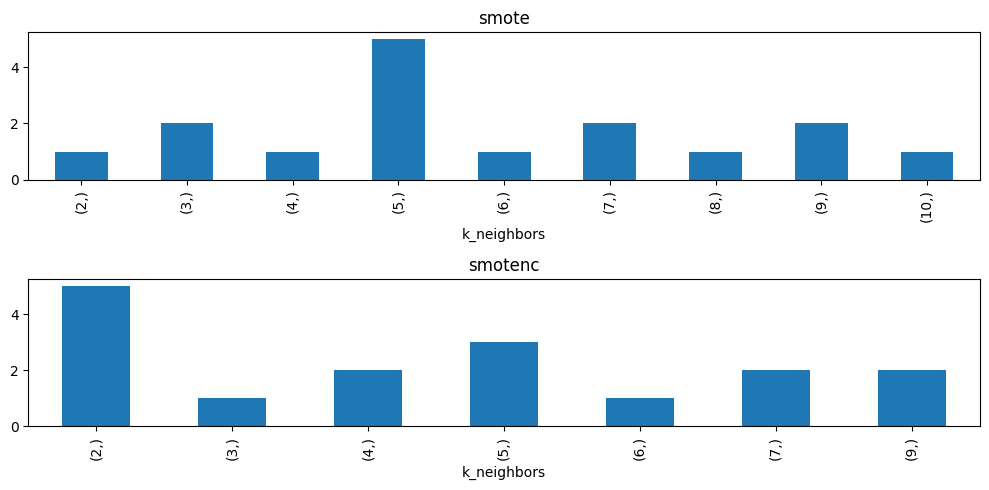

smote


sampling_strategy
0.6                  5
0.7                  5
0.9                  3
1.0                  2
0.8                  1
dtype: int64

smotenc


sampling_strategy
0.6                  7
0.9                  3
1.0                  3
0.7                  2
0.8                  1
dtype: int64

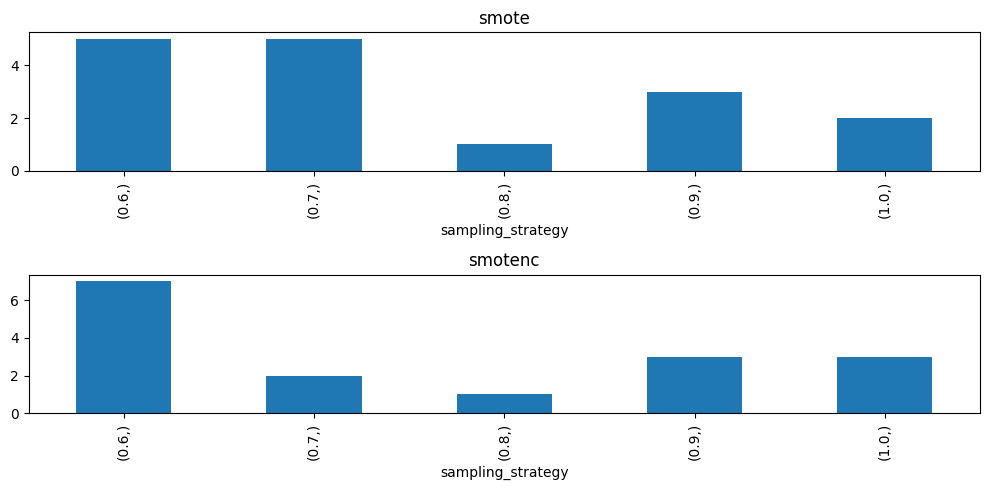

smote


k_neighbors  sampling_strategy
5            0.7                  2
2            0.6                  1
3            0.7                  1
             0.9                  1
4            0.7                  1
5            0.6                  1
             0.8                  1
             1.0                  1
6            0.6                  1
7            0.9                  1
             1.0                  1
8            0.9                  1
9            0.6                  1
             0.7                  1
10           0.6                  1
dtype: int64

smotenc


k_neighbors  sampling_strategy
2            0.6                  2
             0.8                  1
             0.9                  1
             1.0                  1
3            0.6                  1
4            0.6                  1
             1.0                  1
5            0.6                  1
             0.7                  1
             0.9                  1
6            0.6                  1
7            0.6                  1
             0.9                  1
9            0.7                  1
             1.0                  1
dtype: int64

In [9]:
opt_dfs = {
    'smote': smote_opt_df,
    'smotenc': smotenc_opt_df
}

features = [
    ['k_neighbors'],
    ['sampling_strategy'],
    ['k_neighbors', 'sampling_strategy']
]

for i, feature in enumerate(features):
    if i < 2:
        fig, axes = plt.subplots(2, 1, figsize=(10, 5))
    for j, (key, df) in enumerate(opt_dfs.items()):
        print(key)
        display(df[feature].value_counts())
        if i < 2:
            df[feature].value_counts().sort_index(ascending=True).plot(kind='bar', ax=axes[j])
            axes[j].set_title(key)
    fig.tight_layout()
    plt.show()


splashing


k_neighbors
5              4
7              3
2              2
3              2
9              2
4              1
6              1
10             1
dtype: int64

splashing


sampling_strategy
0.6                  5
0.7                  4
0.9                  3
1.0                  3
0.8                  1
dtype: int64

splashing


k_neighbors  sampling_strategy
5            0.7                  2
7            0.9                  2
2            0.8                  1
             1.0                  1
3            0.6                  1
             0.7                  1
4            0.7                  1
5            0.6                  1
             0.9                  1
6            0.6                  1
7            1.0                  1
9            0.6                  1
             1.0                  1
10           0.6                  1
dtype: int64

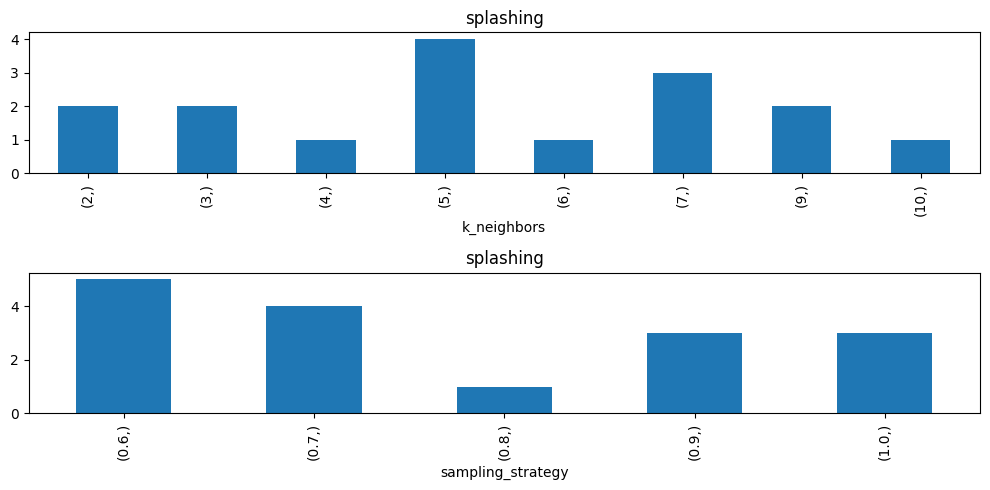

no_fragmentation


k_neighbors
2              4
5              4
4              2
9              2
3              1
6              1
7              1
8              1
dtype: int64

no_fragmentation


sampling_strategy
0.6                  7
0.7                  3
0.9                  3
1.0                  2
0.8                  1
dtype: int64

no_fragmentation


k_neighbors  sampling_strategy
2            0.6                  3
9            0.7                  2
2            0.9                  1
3            0.9                  1
4            0.6                  1
             1.0                  1
5            0.6                  1
             0.7                  1
             0.8                  1
             1.0                  1
6            0.6                  1
7            0.6                  1
8            0.9                  1
dtype: int64

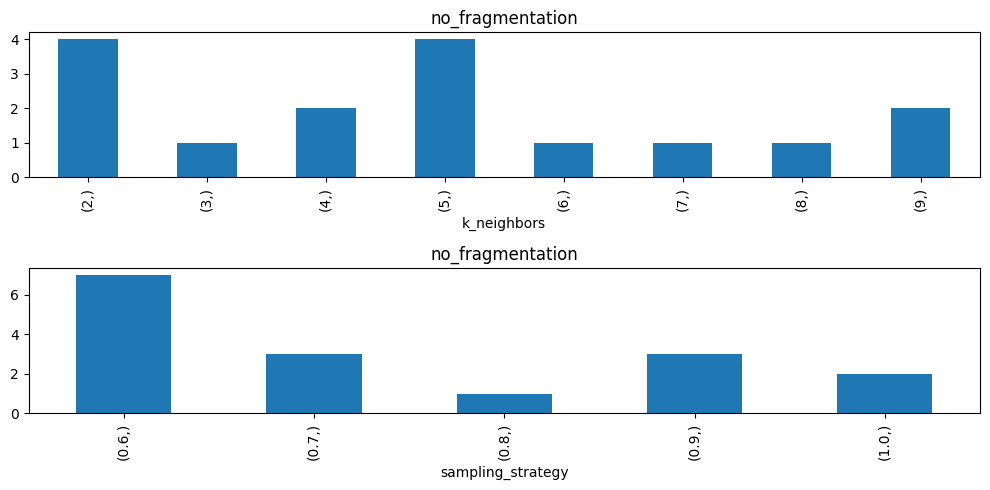

In [10]:

smote_masks = {
    'smote': df_metrics['SMOTE_type'] == 'OPT-SMOTE',
    'smotenc': df_metrics['SMOTE_type'] == 'OPT-SMOTENC',
}

smote_mask = df_metrics['SMOTE_type'].isin(['OPT-SMOTE', 'OPT-SMOTENC'])

target_masks = {
    'splashing': df_metrics['target'] == 'splashing',
    'no_fragmentation': df_metrics['target'] == 'no_fragmentation',
}

features = [
    ['k_neighbors'],
    ['sampling_strategy'],
    ['k_neighbors', 'sampling_strategy']
]


for j, (target, target_mask) in enumerate(target_masks.items()):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5))
    for i, feature in enumerate(features):
        print(target) 
        df = df_metrics[target_mask & smote_mask]
        df = df.apply(get_smote_params, axis=1)
        display(df[feature].value_counts())
        if i < 2:
            df[feature].value_counts().sort_index(ascending=True).plot(kind='bar', ax=axes[i])
            axes[i].set_title(target)
    fig.tight_layout()
    plt.show()


In [11]:
df_metrics['model_class'].unique()

array(['Logit', 'LogisticRegression', 'KNeighborsClassifier', 'SVC',
       'CatBoostClassifier', 'XGBClassifier', 'AdaBoostClassifier',
       'RandomForestClassifier', 'LGBMClassifier'], dtype=object)

In [12]:
smote_mask = df_metrics['SMOTE_type'].isin(['OPT-SMOTE', 'OPT-SMOTENC'])

target_masks = {
    'splashing': df_metrics['target'] == 'splashing',
    'no_fragmentation': df_metrics['target'] == 'no_fragmentation',
}


for target, target_mask in target_masks.items():
    print(target)
    for model in ['CatBoostClassifier', 'XGBClassifier', 'LGBMClassifier']:
        print(model.upper())
        model_mask = df_metrics['model_class'] == model

        features = [
            ['k_neighbors'],
            ['sampling_strategy'],
            ['k_neighbors', 'sampling_strategy']
        ]

        df = df_metrics[target_mask & smote_mask & model_mask]
        df = df.apply(get_smote_params, axis=1)
        display(df[['SMOTE_type'] + features[-1] + ['holdout_test_f1_macro', 'cv_test_f1_macro_median']])


splashing
CATBOOSTCLASSIFIER


,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
60,OPT-SMOTE,10,0.6,0.846814,0.896201
76,OPT-SMOTENC,7,0.9,0.823391,0.860788


XGBCLASSIFIER


,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
62,OPT-SMOTE,7,1.0,0.852826,0.850704
78,OPT-SMOTENC,5,0.9,0.896019,0.873810


LGBMCLASSIFIER


...

,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
61,OPT-SMOTE,5,1.0,0.933862,0.925457
77,OPT-SMOTENC,7,0.6,0.897727,0.898077


XGBCLASSIFIER


,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
63,OPT-SMOTE,8,0.9,0.882524,0.875762
79,OPT-SMOTENC,2,0.6,0.931818,0.854396


LGBMCLASSIFIER


,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
69,OPT-SMOTE,3,0.9,0.885894,0.875762
85,OPT-SMOTENC,4,1.0,0.933862,0.876543


splashing


,SMOTE_type,k_neighbors,sampling_strategy
count,8,8.000000,8.000000
unique,2,NaN,NaN
top,OPT-SMOTENC,NaN,NaN
freq,4,NaN,NaN
mean,NaN,5.875000,0.800000
std,NaN,2.416461,0.151186
min,NaN,2.000000,0.600000
25%,NaN,4.750000,0.675000
50%,NaN,6.000000,0.850000
75%,NaN,7.000000,0.900000


,model_class,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
78,XGBClassifier,OPT-SMOTENC,5,0.9,0.896019,0.873810
62,XGBClassifier,OPT-SMOTE,7,1.0,0.852826,0.850704
60,CatBoostClassifier,OPT-SMOTE,10,0.6,0.846814,0.896201
68,LGBMClassifier,OPT-SMOTE,7,0.9,0.836601,0.898584
84,LGBMClassifier,OPT-SMOTENC,2,0.8,0.836601,0.896201
66,RandomForestClassifier,OPT-SMOTE,4,0.7,0.833300,0.896201
76,CatBoostClassifier,OPT-SMOTENC,7,0.9,0.823391,0.860788
74,SVC,OPT-SMOTENC,5,0.6,0.810348,0.863049


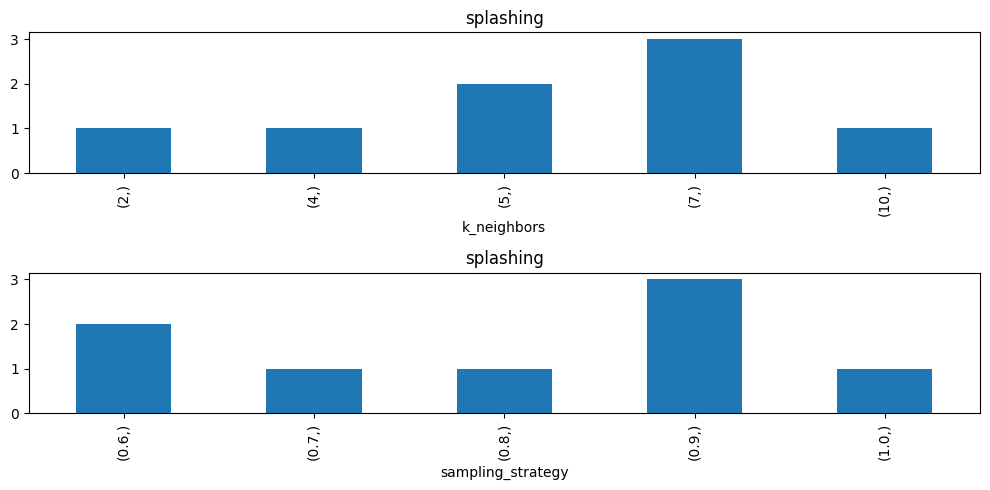

no_fragmentation


,SMOTE_type,k_neighbors,sampling_strategy
count,8,8.00000,8.000000
unique,2,NaN,NaN
top,OPT-SMOTE,NaN,NaN
freq,4,NaN,NaN
mean,NaN,4.87500,0.787500
std,NaN,1.95941,0.180772
min,NaN,2.00000,0.600000
25%,NaN,3.75000,0.600000
50%,NaN,5.00000,0.800000
75%,NaN,5.50000,0.925000


,model_class,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
61,CatBoostClassifier,OPT-SMOTE,5,1.0,0.933862,0.925457
85,LGBMClassifier,OPT-SMOTENC,4,1.0,0.933862,0.876543
79,XGBClassifier,OPT-SMOTENC,2,0.6,0.931818,0.854396
83,RandomForestClassifier,OPT-SMOTENC,5,0.7,0.900794,0.875762
67,RandomForestClassifier,OPT-SMOTE,5,0.6,0.897727,0.898077
77,CatBoostClassifier,OPT-SMOTENC,7,0.6,0.897727,0.898077
69,LGBMClassifier,OPT-SMOTE,3,0.9,0.885894,0.875762
63,XGBClassifier,OPT-SMOTE,8,0.9,0.882524,0.875762


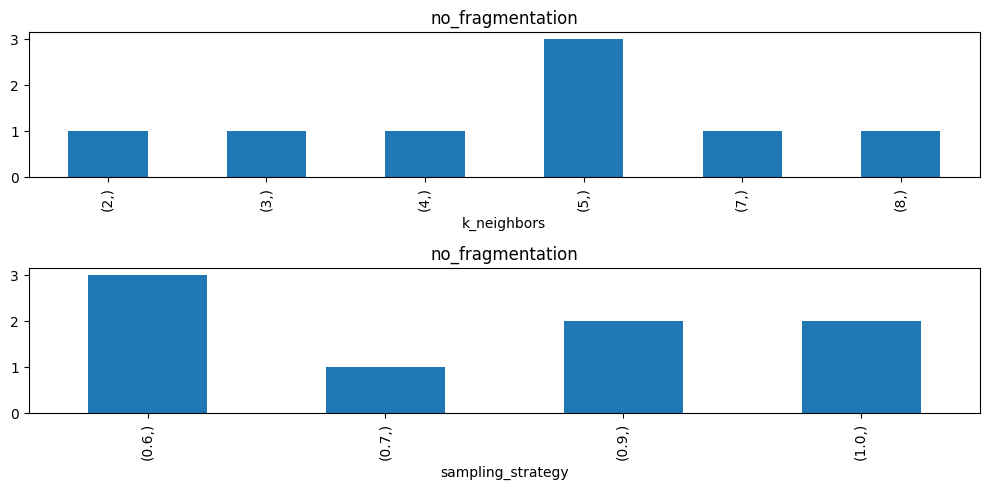

In [13]:
smote_mask = df_metrics['SMOTE_type'].isin(['OPT-SMOTE', 'OPT-SMOTENC'])


target_masks = {
    'splashing': df_metrics['target'] == 'splashing',
    'no_fragmentation': df_metrics['target'] == 'no_fragmentation',
}

features = [
    ['k_neighbors'],
    ['sampling_strategy'],
    ['k_neighbors', 'sampling_strategy']
]

for j, (target, target_mask) in enumerate(target_masks.items()):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5))
    print(target)
    df = df_metrics[target_mask & smote_mask]
    df = df.sort_values(by=['holdout_test_f1_macro', 'cv_test_f1_macro_median'], ascending=False)
    df = df.apply(get_smote_params, axis=1)
    top_df = df[['model_class']+['SMOTE_type'] + features[-1] + ['holdout_test_f1_macro', 'cv_test_f1_macro_median']].head(8)
    display(top_df[['SMOTE_type'] + features[-1]].describe(include='all'))
    display(top_df)
    
    for i, feature in enumerate(features[:-1]):
        top_df[feature].value_counts().sort_index(ascending=True).plot(kind='bar', ax=axes[i])
        axes[i].set_title(target)
    fig.tight_layout()
    plt.show()


splashing


,SMOTE_type,k_neighbors,sampling_strategy
count,4,4.0,4.000000
unique,2,NaN,NaN
top,OPT-SMOTENC,NaN,NaN
freq,2,NaN,NaN
mean,NaN,5.0,0.725000
std,NaN,0.0,0.125831
min,NaN,5.0,0.600000
25%,NaN,5.0,0.675000
50%,NaN,5.0,0.700000
75%,NaN,5.0,0.750000


,model_class,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
78,XGBClassifier,OPT-SMOTENC,5,0.9,0.896019,0.873810
74,SVC,OPT-SMOTENC,5,0.6,0.810348,0.863049
56,KNeighborsClassifier,OPT-SMOTE,5,0.7,0.810348,0.835913
58,SVC,OPT-SMOTE,5,0.7,0.793956,0.863049


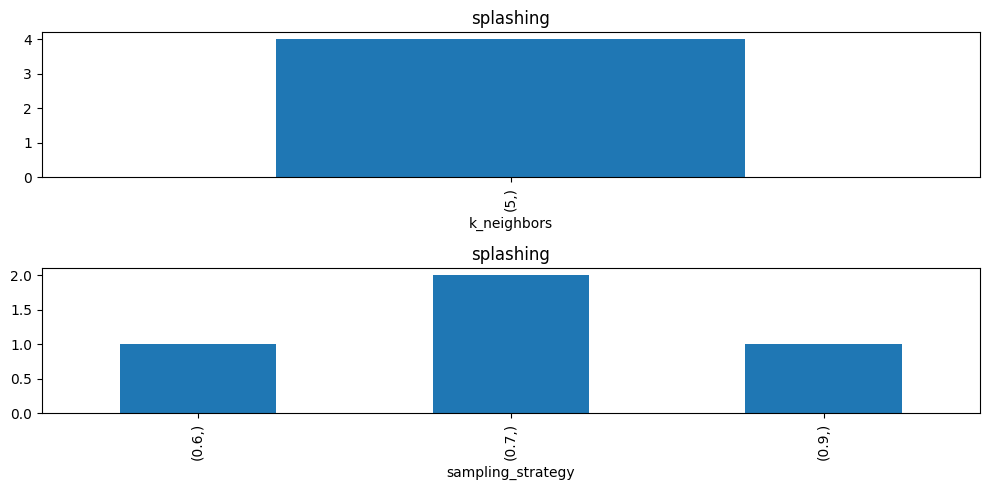

no_fragmentation


,SMOTE_type,k_neighbors,sampling_strategy
count,4,4.0,4.000000
unique,2,NaN,NaN
top,OPT-SMOTE,NaN,NaN
freq,3,NaN,NaN
mean,NaN,5.0,0.775000
std,NaN,0.0,0.170783
min,NaN,5.0,0.600000
25%,NaN,5.0,0.675000
50%,NaN,5.0,0.750000
75%,NaN,5.0,0.850000


,model_class,SMOTE_type,k_neighbors,sampling_strategy,holdout_test_f1_macro,cv_test_f1_macro_median
61,CatBoostClassifier,OPT-SMOTE,5,1.0,0.933862,0.925457
83,RandomForestClassifier,OPT-SMOTENC,5,0.7,0.900794,0.875762
67,RandomForestClassifier,OPT-SMOTE,5,0.6,0.897727,0.898077
57,KNeighborsClassifier,OPT-SMOTE,5,0.8,0.780518,0.854396


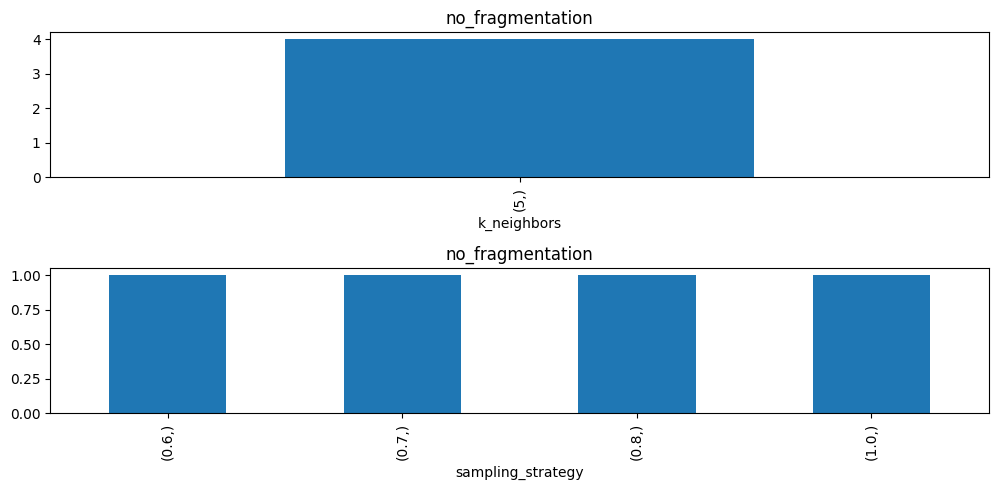

In [17]:
smote_mask = df_metrics['SMOTE_type'].isin(['OPT-SMOTE', 'OPT-SMOTENC'])


target_masks = {
    'splashing': df_metrics['target'] == 'splashing',
    'no_fragmentation': df_metrics['target'] == 'no_fragmentation',
}

features = [
    ['k_neighbors'],
    ['sampling_strategy'],
    ['k_neighbors', 'sampling_strategy']
]

for j, (target, target_mask) in enumerate(target_masks.items()):
    fig, axes = plt.subplots(2, 1, figsize=(10, 5))
    print(target)
    df = df_metrics[target_mask & smote_mask]
    df = df.sort_values(by=['holdout_test_f1_macro', 'cv_test_f1_macro_median'], ascending=False)
    df = df.apply(get_smote_params, axis=1)
    df = df[df['k_neighbors'] == 5]
    df = df[['model_class']+['SMOTE_type'] + features[-1] + ['holdout_test_f1_macro', 'cv_test_f1_macro_median']]
    display(df[['SMOTE_type'] + features[-1]].describe(include='all'))
    display(df)
    
    for i, feature in enumerate(features[:-1]):
        df[feature].value_counts().sort_index(ascending=True).plot(kind='bar', ax=axes[i])
        axes[i].set_title(target)
    fig.tight_layout()
    plt.show()


# **CONCLUSION:**

- optimization of all models without SMOTE
- optimization on SMOTE/SMOTENC with default features (k_neighbors = 5, sampling_strategy='auto')
- optimization on SMOTE/SMOTENC with default features (k_neighbors = 5, sampling_strategy=0.7)